In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import special_ortho_group
from scipy.special import erf


def generate_eigenvalues(ranges: list[tuple], nums: list, rng):
    groups = []
    for r, num in zip(ranges, nums):
        groups.append(rng.random(num) * (r[1] - r[0]) + r[0])
    return np.diag(np.concatenate(groups))


def random_rotation(d, rng):
    group = special_ortho_group(dim=d, seed=int(rng.integers(0, 10000)))
    return group.rvs(1)


def true_gradient(Q, theta, target):
    """True (noiseless) gradient ∇L(θ) = Q(θ − x*)"""
    return Q @ (theta - target)


def sample_gradient(Q, theta, target, nu, rng):
    """Stochastic gradient g = Q(θ − x) where x ~ N(x*, ν²I)"""
    noise = rng.normal(0, nu, size=len(target)) if nu > 0 else np.zeros(len(target))
    return Q @ (theta - (target + noise))


def optimal_step_sgd(Q, stoch_grad, true_grad):
    """
    Per-sample optimal step for SGD direction z = −g.
    Minimises L(θ − α g) for the observed g:
        α* = gᵀ∇L / (gᵀQg)
    Uses the true gradient ∇L (known in the synthetic sQP setting).
    At ν=0, g = ∇L and this recovers the steepest-descent line-search.
    """
    numer = np.dot(stoch_grad, true_grad)
    denom = np.dot(stoch_grad, Q @ stoch_grad)
    return numer / denom if abs(denom) > 1e-14 else 0.0


def optimal_step_ssd(Q, stoch_grad, true_grad):
    """
    Per-sample optimal step for SSD direction z = −sign(g).
    Minimises L(θ − α sign(g)) for the observed g:
        α* = sign(g)ᵀ∇L / (sign(g)ᵀQ sign(g))
    Uses the true gradient ∇L (known in the synthetic sQP setting).
    """
    s = np.sign(stoch_grad)
    numer = np.dot(s, true_grad)
    denom = np.dot(s, Q @ s)
    return numer / denom if abs(denom) > 1e-14 else 0.0


def objective_loss(Q, theta, target):
    """True quadratic loss L(θ) = ½ (θ − x*)ᵀ Q (θ − x*)"""
    diff = theta - target
    return 0.5 * np.dot(diff, Q @ diff)


def run_experiment(Q, target, nu, n_steps, rng):
    """
    Run SGD and SSD with their per-sample optimal local step sizes.
    Both methods receive the same sequence of stochastic gradients.
    """
    d = len(target)
    theta_sgd = np.zeros(d)
    theta_ssd = np.zeros(d)
    losses_sgd = [objective_loss(Q, theta_sgd, target)]
    losses_ssd = [objective_loss(Q, theta_ssd, target)]

    for _ in range(n_steps):
        # SGD
        tg = true_gradient(Q, theta_sgd, target)
        g  = sample_gradient(Q, theta_sgd, target, nu, rng)
        alpha = optimal_step_sgd(Q, g, tg)
        theta_sgd -= alpha * g
        losses_sgd.append(objective_loss(Q, theta_sgd, target))

        # SSD
        tg = true_gradient(Q, theta_ssd, target)
        g  = sample_gradient(Q, theta_ssd, target, nu, rng)
        alpha = optimal_step_ssd(Q, g, tg)
        theta_ssd -= alpha * np.sign(g)
        losses_ssd.append(objective_loss(Q, theta_ssd, target))

    return np.array(losses_sgd), np.array(losses_ssd)


/Users/user/Manchester/reproducibility-challenge/.venv/lib/python3.10/site-packages/scipy/stats/_multivariate.py:3685: RuntimeWarning: divide by zero encountered in matmul
  H[..., :, n:] -= np.matmul(H[..., :, n:], xcol) * xrow
/Users/user/Manchester/reproducibility-challenge/.venv/lib/python3.10/site-packages/scipy/stats/_multivariate.py:3685: RuntimeWarning: overflow encountered in matmul
  H[..., :, n:] -= np.matmul(H[..., :, n:], xcol) * xrow
/Users/user/Manchester/reproducibility-challenge/.venv/lib/python3.10/site-packages/scipy/stats/_multivariate.py:3685: RuntimeWarning: invalid value encountered in matmul
  H[..., :, n:] -= np.matmul(H[..., :, n:], xcol) * xrow
/var/folders/zv/qz265l2n39d9krn_9fvzt54w0000gp/T/ipykernel_74670/351073833.py:23: RuntimeWarning: divide by zero encountered in matmul
  Q_rot_well  = R @ lamb1 @ R.T
/var/folders/zv/qz265l2n39d9krn_9fvzt54w0000gp/T/ipykernel_74670/351073833.py:23: RuntimeWarning: overflow encountered in matmul
  Q_rot_well  = R @ lamb

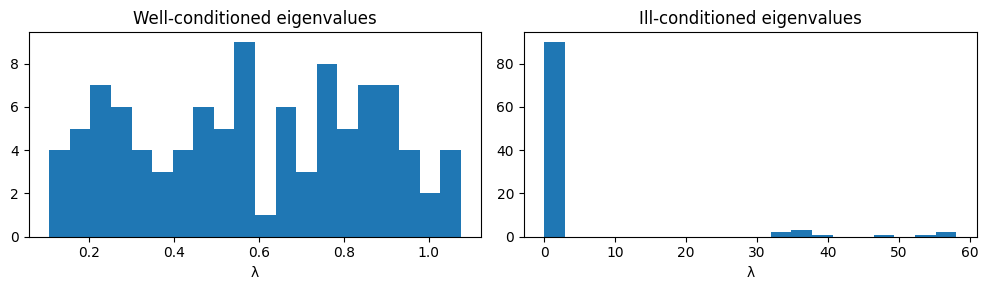

In [2]:
seed = 42
rng = np.random.default_rng(seed)

d = 100
target = np.ones(d)
noise_levels = [0, 0.1, 4.0]   # ν values from the paper
n_steps = 300

# --- Eigenvalue matrices (paper §3.1) ---
# (a) well-conditioned: λᵢ ~ Uniform[0.1, 1.1]
lamb1 = generate_eigenvalues([(0.1, 1.1)], [100], rng)
# (b) ill-conditioned: 90% from [0,1], 10% from [30,60]
lamb2 = generate_eigenvalues([(0, 1), (30, 60)], [90, 10], rng)

eig1 = np.diag(lamb1)
eig2 = np.diag(lamb2)

# --- Random rotation R drawn uniformly from SO(100) ---
R = random_rotation(d, rng)

# --- Four QP matrices: axis-aligned (Q=Λ) and rotated (Q=RΛRᵀ) ---
Q_diag_well = lamb1
Q_rot_well  = R @ lamb1 @ R.T
Q_diag_ill  = lamb2
Q_rot_ill   = R @ lamb2 @ R.T

qps = [
    (Q_diag_well, 'Well-conditioned, axis-aligned'),
    (Q_rot_well,  'Well-conditioned, rotated'),
    (Q_diag_ill,  'Ill-conditioned, axis-aligned'),
    (Q_rot_ill,   'Ill-conditioned, rotated'),
]

# Show eigenvalue spectra
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].hist(eig1, bins=20)
axes[0].set_title('Well-conditioned eigenvalues')
axes[0].set_xlabel('λ')
axes[1].hist(eig2, bins=20)
axes[1].set_title('Ill-conditioned eigenvalues')
axes[1].set_xlabel('λ')
plt.tight_layout()
plt.show()


/var/folders/zv/qz265l2n39d9krn_9fvzt54w0000gp/T/ipykernel_74670/2382304123.py:59: RuntimeWarning: divide by zero encountered in matmul
  return 0.5 * np.dot(diff, Q @ diff)
/var/folders/zv/qz265l2n39d9krn_9fvzt54w0000gp/T/ipykernel_74670/2382304123.py:59: RuntimeWarning: overflow encountered in matmul
  return 0.5 * np.dot(diff, Q @ diff)
/var/folders/zv/qz265l2n39d9krn_9fvzt54w0000gp/T/ipykernel_74670/2382304123.py:59: RuntimeWarning: invalid value encountered in matmul
  return 0.5 * np.dot(diff, Q @ diff)
/var/folders/zv/qz265l2n39d9krn_9fvzt54w0000gp/T/ipykernel_74670/2382304123.py:21: RuntimeWarning: divide by zero encountered in matmul
  return Q @ (theta - target)
/var/folders/zv/qz265l2n39d9krn_9fvzt54w0000gp/T/ipykernel_74670/2382304123.py:21: RuntimeWarning: overflow encountered in matmul
  return Q @ (theta - target)
/var/folders/zv/qz265l2n39d9krn_9fvzt54w0000gp/T/ipykernel_74670/2382304123.py:21: RuntimeWarning: invalid value encountered in matmul
  return Q @ (theta - ta

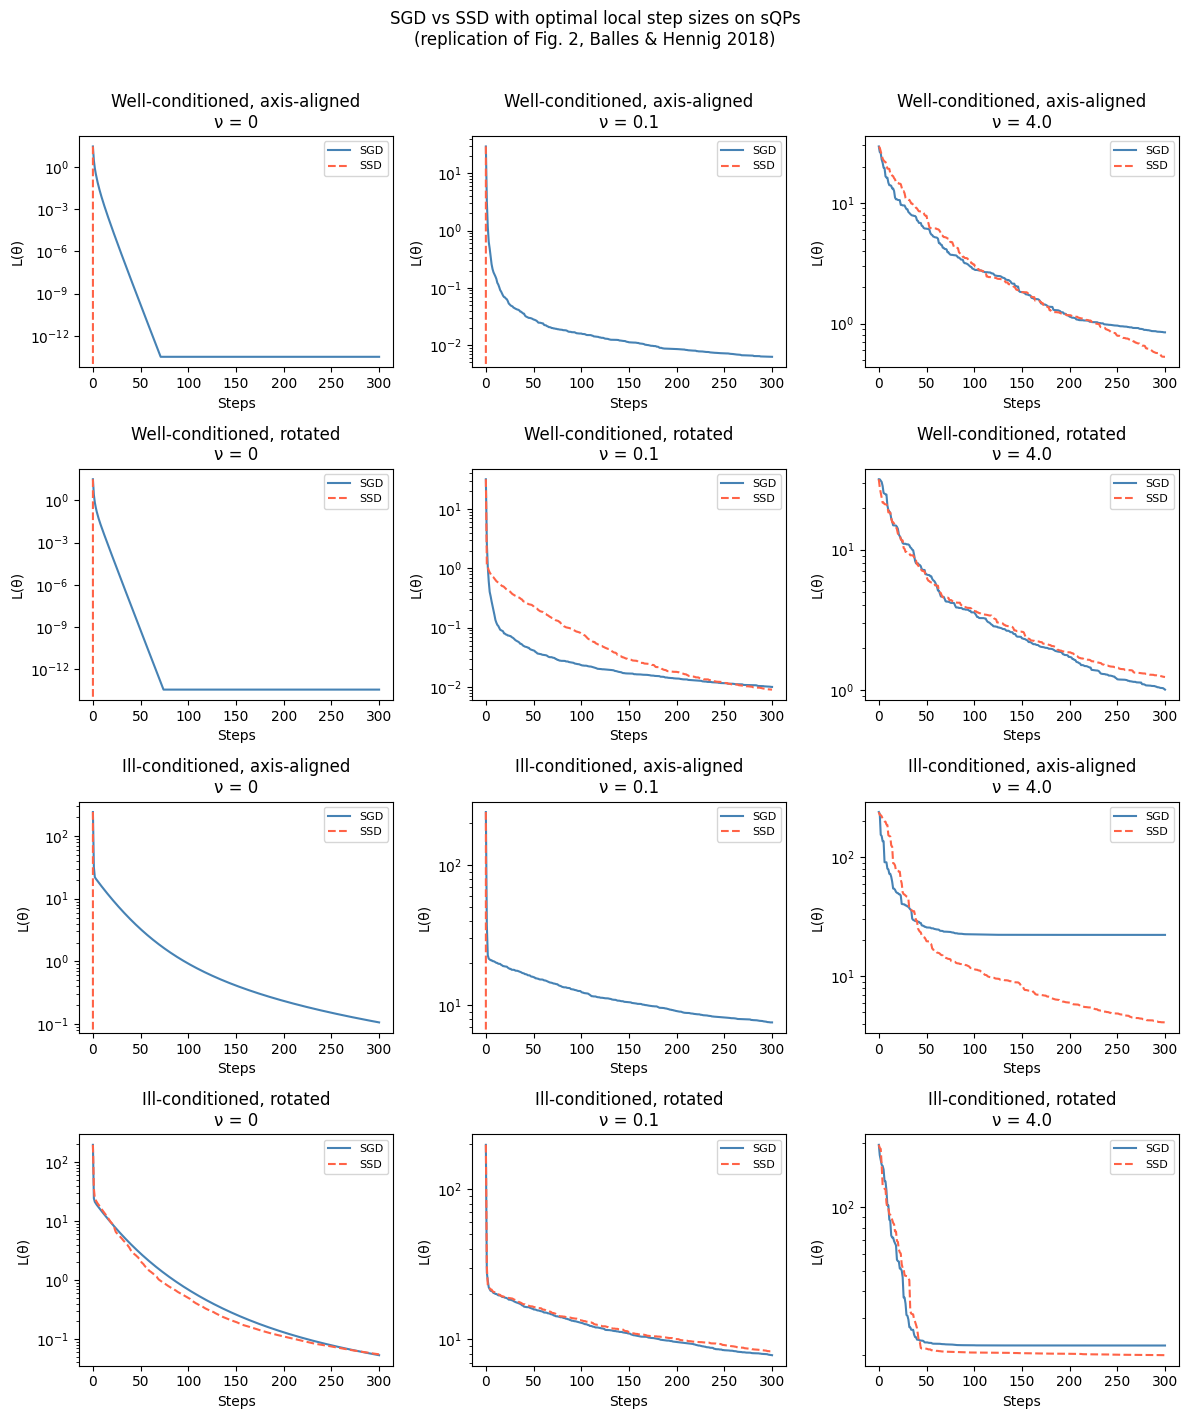

In [3]:
steps = np.arange(n_steps + 1)

fig, axes = plt.subplots(4, 3, figsize=(12, 14))

for row, (Q, label) in enumerate(qps):
    for col, nu in enumerate(noise_levels):
        rng_exp = np.random.default_rng(seed + row * 100 + col)
        losses_sgd, losses_ssd = run_experiment(Q, target, nu, n_steps, rng_exp)

        ax = axes[row, col]
        ax.semilogy(steps, losses_sgd, color='steelblue', label='SGD')
        ax.semilogy(steps, losses_ssd, color='tomato', linestyle='--', label='SSD')
        ax.set_xlabel('Steps')
        ax.set_ylabel('L(θ)')
        ax.set_title(f'{label}\nν = {nu}')
        ax.legend(fontsize=8)

plt.suptitle(
    'SGD vs SSD with optimal local step sizes on sQPs\n'
    r'(replication of Fig. 2, Balles & Hennig 2018)',
    y=1.01
)
plt.tight_layout()
plt.show()
